In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F

print(sys.version_info)
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

seed = 42

D:\AAA_SoftWare\python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


sys.version_info(major=3, minor=14, micro=2, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 2.4.1
pandas 3.0.0
sklearn 1.8.0
torch 2.10.0+cu130
cuda:0


# 数据准备

In [2]:
from torchvision import datasets
from torchvision.transforms import ToTensor, Resize, Compose, ConvertImageDtype, Normalize
from torchvision.transforms import (
    RandomHorizontalFlip, RandomResizedCrop, ColorJitter, Compose
)

from pathlib import Path

DATA_DIR = Path(r"D:\Code\Py_code_2026\2026py\dataset\archive")


class MonkeyDataset(datasets.ImageFolder):
    def __init__(self, mode, transform=None):
        # 1. 根据mode选择训练/验证集目录
        if mode == "train":
            root = DATA_DIR / "training"  # 拼接路径：根目录/training
        elif mode == "val":
            root = DATA_DIR / "validation"  # 拼接路径：根目录/validation
        else:
            raise ValueError("mode should be one of the following: train, val, but got {}".format(mode))
        # 2. 调用父类ImageFolder的初始化方法
        super().__init__(root, transform)
        '''
        root：数据集目录。子类 MonkeyDataset 根据 mode（train/val）拼接的数据集目录（比如 DATA_DIR / "training"），父类需要这个路径来遍历图片
        transform：图片处理的规则。定义的图片预处理流水线（缩放、标准化等），父类会把这个变换绑定到数据集，确保每张图片加载时都执行相同的预处理
        '''
        # self有两个方法，sample和targets，self.samples里边是图片路径及标签 [(path, label), (path, label),...]
        self.targets = [s[1] for s in self.samples]  # label标签取出来


# 预先设定的图片尺寸
img_h, img_w = 128, 128
# 上面transform的实现，Compose是 PyTorch 提供的 “变换容器”，作用是按顺序执行列表中的所有变换
# 下方的compose会过拟合
# transform = Compose([
#     Resize((img_h, img_w)),  # 统一图片尺寸
#     ToTensor(),  # 转换为 PyTorch 张量
#     # 预先统计的
#     Normalize([0.4363, 0.4328, 0.3291], [0.2085, 0.2032, 0.1988]),  # 标准化（Z-score 归一化），分别是RGB三个通道的均值和标准差
#     ConvertImageDtype(torch.float),  # 转换为float类型，确保数据类型统一
# ])  #数据预处理

# 训练集用增强后的 transform
train_transform = Compose([
    Resize((140, 140)),          # 先放大一点，方便随机裁剪
    RandomResizedCrop((img_h, img_w), scale=(0.8, 1.0)),  # 随机裁剪
    RandomHorizontalFlip(p=0.5),  # 50% 概率水平翻转
    ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),  # 颜色抖动
    ToTensor(),
    Normalize([0.4363, 0.4328, 0.3291], [0.2085, 0.2032, 0.1988]),  # 用你之前统计的 mean/std
    ConvertImageDtype(torch.float),
])

# 验证集 transform 保持不变，绝对不能加增强！
val_transform = Compose([
    Resize((img_h, img_w)),
    ToTensor(),
    Normalize([0.4363, 0.4328, 0.3291], [0.2085, 0.2032, 0.1988]),
    ConvertImageDtype(torch.float),
])

train_ds = MonkeyDataset("train", transform=train_transform)  # 调用父类transform的方法
val_ds = MonkeyDataset("val", transform=val_transform)

print("load {} images from training dataset".format(len(train_ds)))
print("load {} images from validation dataset".format(len(val_ds)))

load 1097 images from training dataset
load 272 images from validation dataset


将上方Normalize注释，用下方代码求出均值方差，作为Normalize的参数，用于训练

In [3]:
# 统计数据集（如 train_ds）中所有图片张量的 RGB 三个通道各自的均值（mean）和标准差（std），最终输出的 mean 和 std 会作为 Normalize 变换的参数，实现图片张量的标准化（让每个通道均值≈0、方差≈1）
def cal_mean_std(ds):
    mean = 0.
    std = 0.
    for img, _ in ds:  # 遍历数据集中的每个样本：img是预处理后的张量，_是标签（用不到）
        #img 是经过 transform 处理后的张量，维度为 (3, 128, 128)（C×H×W，对应 RGB 通道、高度、宽度）
        mean += img.mean(dim=(1, 2))  # 对每张图片的每个通道，计算H×W维度的均值，然后累加到mean
        std += img.std(dim=(1, 2))  # 对每张图片的每个通道，计算H×W维度的标准差，然后累加到std
    mean /= len(ds)  # 除以样本总数，得到全局均值
    std /= len(ds)  # 除以样本总数，得到全局标准差
    return mean, std

# 经过 normalize 后 均值为0，方差为1
# print(cal_mean_std(train_ds))

将数据加载到 DataLoader 中，用于批量训练和验证

In [4]:
import torch.nn as nn
from torch.utils.data.dataloader import DataLoader

batch_size = 64
# 从数据集到dataloader，num_workers参数不能加，否则会报错
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
#dataloader的作用是：将数据集分成多个batch，每个batch包含32个样本
#shuffle=True表示每个epoch都要打乱样本顺序

In [5]:
for imgs, labels in train_loader:
    print(imgs.shape)
    print(labels.shape)
    break

torch.Size([64, 3, 128, 128])
torch.Size([64])


# 定义模型

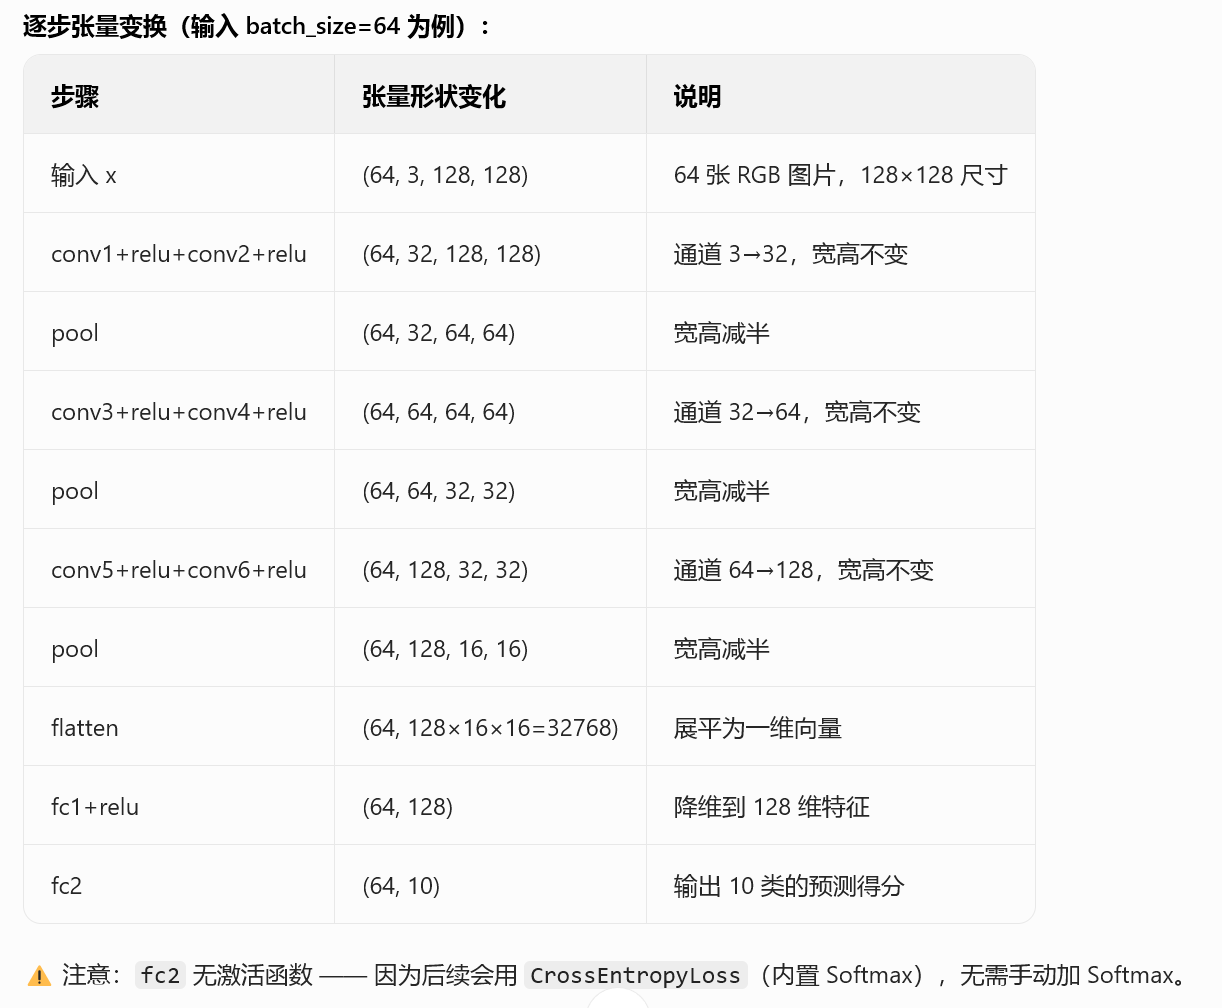

In [6]:
class CNN(nn.Module):
    def __init__(self, num_classes=10, activation="relu"):
        super(CNN, self).__init__()  #继承CNN
        self.activation = F.relu if activation == "relu" else F.selu  #激活函数选择
        # torch.Size([64, 3, 128, 128]) → 64个样本，3通道，128×128尺寸
        # 第1组卷积：输入3通道（RGB）→ 输出32通道，卷积核大小（3→3x3 的正方形核），padding="same"是在做填充：保证卷积后图像的宽 / 高不变（公式：输出尺寸 = 输入尺寸 / 步长，步长默认 1）
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding="same")
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding="same")
        #池化层（MaxPool2d）：降维 + 保留关键特征
        # 第1组池化：2x2 窗口，步长 2，输出尺寸 = 128 / 2 = 64
        self.pool = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding="same")
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding="same")
        self.conv5 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding="same")
        self.conv6 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding="same")
        #展平层（Flatten）：从 “特征图” 到 “一维向量”
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(0.5)  # 丢弃 50% 神经元
        # input shape is (3, 128, 128) so the flatten output shape is 128 * 16 * 16
        #全连接层（Linear）：分类决策
        self.fc1 = nn.Linear(128 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, num_classes)
        '''
        128 * 16 * 16是怎么来的：
        输入图像尺寸是 (3, 128, 128)，经过 3 次卷积 + 池化后，尺寸逐步缩小：
        第 1 次池化：128×128 → 64×64（宽高减半），通道 32；
        第 2 次池化：64×64 → 32×32，通道 64；
        第 3 次池化：32×32 → 16×16，通道 128；
        最终卷积输出是 (batch, 128, 16, 16)，展平后就是 128×16×16。
        '''
        self.init_weights()

    def init_weights(self):
        """使用 xavier 均匀分布来初始化全连接层、卷积层的权重 W"""
        for m in self.modules():  # self.modules()：遍历网络中所有层（卷积、池化、全连接等）
            if isinstance(m, (nn.Linear, nn.Conv2d)):  # 只对 nn.Linear（全连接）和 nn.Conv2d（卷积）做初始化（池化层无参数，无需初始化）
                nn.init.xavier_uniform_(m.weight)  # 通过均匀分布初始化权重，让网络各层输入 / 输出方差一致，适用于 ReLU/SELU 等激活函数的初始化方法，能让梯度在传播中更稳定
                nn.init.zeros_(m.bias)  # 偏置初始化为0

    def forward(self, x):  # 前向传播（数据的流动路径）
        act = self.activation  # 简化激活函数调用（等价于act=F.relu/act=F.selu）
        # 第1组：conv1→激活→conv2→激活→池化
        x = self.pool(act(self.conv2(act(self.conv1(x)))))
        # 第2组：conv3→激活→conv4→激活→池化
        x = self.pool(act(self.conv4(act(self.conv3(x)))))
        # 第3组：conv5→激活→conv6→激活→池化
        x = self.pool(act(self.conv6(act(self.conv5(x)))))
        # 展平：4维→2维
        x = self.flatten(x)
        x = self.dropout(x)  # 全连接前加 Dropout
        # 全连接1 + 激活
        x = act(self.fc1(x))
        # 全连接2（输出分类结果，无激活）
        x = self.fc2(x)
        return x

# 遍历并打印每层可训练参数的数量
for idx, (key, value) in enumerate(CNN().named_parameters()):
    print(f"{key}\tparamerters num: {np.prod(value.shape)}")

conv1.weight	paramerters num: 864
conv1.bias	paramerters num: 32
conv2.weight	paramerters num: 9216
conv2.bias	paramerters num: 32
conv3.weight	paramerters num: 18432
conv3.bias	paramerters num: 64
conv4.weight	paramerters num: 36864
conv4.bias	paramerters num: 64
conv5.weight	paramerters num: 73728
conv5.bias	paramerters num: 128
conv6.weight	paramerters num: 147456
conv6.bias	paramerters num: 128
fc1.weight	paramerters num: 4194304
fc1.bias	paramerters num: 128
fc2.weight	paramerters num: 1280
fc2.bias	paramerters num: 10


# 训练

pytorch的训练需要自行实现，包括
1. 定义损失函数
2. 定义优化器
3. 定义训练步
4. 训练

In [7]:
from sklearn.metrics import accuracy_score

# 装饰器：禁用PyTorch的梯度计算机制
# 评估阶段不需要反向传播更新参数，关闭梯度可节省显存、提升计算速度，避免不必要的内存占用
@torch.no_grad()
def evaluating(model, dataloader, loss_fct):
    """
    模型评估函数：在验证集/测试集上计算模型的平均损失和准确率
    参数说明：
        model: 待评估的PyTorch模型（如定义的CNN）
        dataloader: 验证/测试数据集的DataLoader，提供批量数据
        loss_fct: 损失函数（如CrossEntropyLoss），用于计算预测损失
    返回值：
        np.mean(loss_list): 整个数据集的平均损失（标量）
        acc: 整个数据集的分类准确率（标量，0~1之间）
    """
    # 初始化空列表，用于存储每个batch的损失值
    loss_list = []
    # 初始化空列表，用于存储整个数据集的预测类别（一维列表）
    pred_list = []
    # 初始化空列表，用于存储整个数据集的真实类别（一维列表）
    label_list = []

    # 遍历DataLoader，逐批次处理数据（每次取一个batch的图片和标签）
    for datas, labels in dataloader:
        # 将图片数据从CPU移到指定设备（GPU/CPU），和模型保持同设备
        datas = datas.to(device)
        # 将标签数据从CPU移到指定设备，和图片数据保持同设备
        labels = labels.to(device)

        # 模型前向传播：输入图片数据，输出各分类的原始得分（logits，未经过softmax）
        logits = model(datas)

        # 计算当前batch的损失：用损失函数对比logits和真实标签
        loss = loss_fct(logits, labels)
        # 将损失值（tensor类型）转为Python标量，并添加到损失列表
        loss_list.append(loss.item())

        # 预测类别：对logits按最后一维（分类维度）取argmax，得到每个样本的预测类别索引
        # 例如logits形状为[64,10]（64个样本，10类），argmax后得到[64,]的一维tensor
        preds = logits.argmax(axis=-1)

        # 收集预测结果：先将tensor从GPU移到CPU→转为numpy数组→转为列表，添加到总预测列表
        pred_list.extend(preds.cpu().numpy().tolist())
        # 收集真实标签：同上，将真实标签转为列表后添加到总标签列表
        label_list.extend(labels.cpu().numpy().tolist())

    # 计算整个数据集的准确率：对比真实标签和预测标签的匹配程度（sklearn的accuracy_score）
    acc = accuracy_score(label_list, pred_list)
    # 返回平均损失（所有batch损失的均值）和准确率
    return np.mean(loss_list), acc

# TensorBoard 可视化

In [8]:
from torch.utils.tensorboard import SummaryWriter
import torch

class TensorBoardCallback:
    """
    TensorBoard 可视化回调类：封装 TensorBoard 日志记录逻辑，简化训练过程中
    模型结构图绘制、损失/准确率/学习率曲线记录的操作，让训练过程可可视化追踪。
    """
    def __init__(self, log_dir, flush_secs=10):
        """
        初始化 TensorBoard 日志写入器
        Args:
            log_dir (str): 日志文件的保存路径（如 "runs/monkeys-cnn-relu"），不同实验建议用不同路径，避免日志混淆
            flush_secs (int, optional): 日志写入磁盘的间隔秒数（默认10秒）。TensorBoard 会先缓存日志，每隔flush_secs秒写入磁盘，避免频繁IO操作，提升训练效率
        """
        # 实例化 SummaryWriter（TensorBoard 核心类），负责日志的生成和写入
        self.writer = SummaryWriter(
            log_dir=log_dir,  # 日志保存路径，启动TensorBoard时需指定此路径
            flush_secs=flush_secs  # 缓存日志后批量写入磁盘的间隔
        )

    # 绘制模型结构图
    def draw_model(self, model, input_shape):
        """
        在 TensorBoard 的「Graphs」标签页绘制神经网络的计算图（拓扑结构）
        作用：直观查看模型的层结构、数据流向、参数维度，方便调试模型结构是否正确

        Args:
            model (nn.Module): 待可视化的PyTorch模型（如定义的CNN类实例）
            input_shape (list/tuple): 模型输入数据的形状（batch维度+通道+高+宽），
                                      例如 [1, 3, 128, 128] 表示「1个样本、3通道、128x128像素」
        """
        # 生成符合输入形状的随机张量（假数据），用于让模型执行一次前向传播
        # 因为TensorBoard需要通过「实际数据流向」来解析模型结构
        dummy_input = torch.randn(input_shape)
        # add_graph：记录模型的计算图，TensorBoard的Graphs标签页可查看
        self.writer.add_graph(
            model,  # 待可视化的模型
            input_to_model=dummy_input  # 假输入数据，用于触发模型前向传播
        )

    # 记录损失曲线（训练集+测试/验证集）
    def add_loss_scalars(self, step, loss, test_loss):
        """
        在 TensorBoard 的「Scalars」标签页绘制损失曲线（训练损失+测试/验证损失）
        作用：对比训练/测试损失，判断模型是否过拟合（如训练损失降、测试损失升则过拟合）

        Args:
            step (int): 全局步数/轮次（横坐标X轴，通常是训练的step数）
            loss (float): 当前step的训练集损失值
            test_loss (float): 当前step的测试/验证集损失值
        """
        self.writer.add_scalars(
            main_tag="training/loss",  # 图表的主标题（Scalars页面的分类标签）
            # 子标签-数值字典：key是曲线名称，value是对应数值，可同时绘制多条曲线
            tag_scalar_dict={"loss": loss, "test_loss": test_loss},
            global_step=step,  # 横坐标（X轴），对应训练的步数/轮次
        )
        # 注：add_scalars 可同时绘制多条曲线（对比更方便），而 add_scalar 只能画单条

    # 记录准确率曲线（训练集+测试/验证集）
    def add_acc_scalars(self, step, acc, test_acc):
        """
        在 TensorBoard 的「Scalars」标签页绘制准确率曲线（训练准确率+测试/验证准确率）
        作用：对比训练/测试准确率，判断模型泛化能力（如训练准确率高、测试低则过拟合）

        Args:
            step (int): 全局步数/轮次（横坐标X轴）
            acc (float): 当前step的训练集准确率（0~1之间）
            test_acc (float): 当前step的测试/验证集准确率（0~1之间）
        """
        self.writer.add_scalars(
            main_tag="training/accuracy",  # 准确率曲线的主标题
            tag_scalar_dict={"accuracy": acc, "test_accuracy": test_acc},  # 训练/测试准确率曲线
            global_step=step,  # 横坐标（训练步数）
        )

    # 记录学习率曲线
    def add_lr_scalars(self, step, learning_rate):
        """
        在 TensorBoard 的「Scalars」标签页绘制学习率曲线
        作用：追踪训练过程中学习率的变化（如是否随步数衰减、是否设置合理）

        Args:
            step (int): 全局步数/轮次（横坐标X轴）
            learning_rate (float): 当前step的优化器学习率（如0.001、0.0001）
        """
        self.writer.add_scalars(
            main_tag="training/learning_rate",  # 学习率曲线的主标题
            tag_scalar_dict={"learning_rate": learning_rate},  # 学习率曲线（单条）
            global_step=step,  # 横坐标（训练步数）
        )

    def __call__(self, step, **kwargs):
        """
        魔法方法：让类的实例可以像函数一样被调用，统一分发日志记录逻辑
        作用：训练过程中只需调用 callback(step, loss=..., acc=...)，即可自动判断要记录哪些日志，
             无需手动调用add_loss_scalars/add_acc_scalars等方法，简化代码

        Args:
            step (int): 全局训练步数（横坐标X轴）
            **kwargs: 可变关键字参数，支持传入 loss/test_loss/acc/test_acc/lr 等参数
        """
        # ========== 1. 记录损失曲线 ==========
        # pop(key, None)：从kwargs中取出参数，若不存在则返回None，避免KeyError
        loss = kwargs.pop("loss", None)  # 取出训练损失
        test_loss = kwargs.pop("test_loss", None)  # 取出测试/验证损失
        # 只有同时拿到训练损失和测试损失时，才记录损失曲线
        if loss is not None and test_loss is not None:
            self.add_loss_scalars(step, loss, test_loss)

        # ========== 2. 记录准确率曲线 ==========
        acc = kwargs.pop("acc", None)  # 取出训练准确率
        test_acc = kwargs.pop("test_acc", None)  # 取出测试/验证准确率
        # 只有同时拿到训练准确率和测试准确率时，才记录准确率曲线
        if acc is not None and test_acc is not None:
            self.add_acc_scalars(step, acc, test_acc)

        # ========== 3. 记录学习率曲线 ==========
        learning_rate = kwargs.pop("lr", None)  # 取出当前学习率
        # 拿到学习率就记录（无需对比值，单条曲线即可）
        if learning_rate is not None:
            self.add_lr_scalars(step, learning_rate)

# SaveBest

In [9]:
class SaveCheckpointsCallback:
    """
    模型权重（Checkpoint）保存回调类：封装训练过程中模型权重的保存逻辑，支持
    「按步数定期保存」「仅保存最优模型」两种模式，避免训练中断丢失进度、方便后续加载最优模型推理/继续训练。
    """
    def __init__(self, save_dir, save_step=5000, save_best_only=True):
        """
        初始化模型保存回调类
        Args:
            save_dir (str): 模型权重文件的保存目录
            save_step (int, optional): 保存权重的步数间隔（默认5000步）。即每训练save_step步，触发一次权重保存逻辑
            save_best_only (bool, optional): 是否仅保存「最优模型」（默认True）。
            - True：仅当验证集指标（如准确率）优于历史最优时，才覆盖保存"best.ckpt"
            - False：按save_step间隔保存多个权重文件（命名为「步数.ckpt」），保留所有版本
        """
        # 模型权重保存目录
        self.save_dir = save_dir
        # 保存权重的步数间隔（控制保存频率，避免频繁IO）
        self.save_step = save_step
        # 是否仅保存最优模型（节省磁盘空间，聚焦最佳结果）
        self.save_best_only = save_best_only
        # 记录历史最优指标（初始值-1，适用于准确率等「越大越好」的指标）
        self.best_metrics = -1

        # ========== 工程化细节：自动创建保存目录 ==========
        # 若保存目录不存在，自动创建（避免手动创建目录的繁琐，防止FileNotFoundError）
        if not os.path.exists(self.save_dir):
            os.mkdir(self.save_dir)

    def __call__(self, step, state_dict, metric=None):
        """
        魔法方法：让类实例可像函数一样调用，触发模型权重保存逻辑
        Args:
            step (int): 当前训练的全局步数（用于判断是否达到保存间隔、命名权重文件）
            state_dict (OrderedDict): 模型的状态字典（model.state_dict()），包含所有可训练参数的权重
            metric (float, optional): 验证集评估指标（如准确率、F1值），仅当save_best_only=True时需要，
                                      用于判断是否为「最优模型」
        """
        # ========== 第一步：判断是否达到保存步数间隔 ==========
        # 仅当当前步数是save_step的整数倍时，才执行保存逻辑（控制保存频率）
        # 例如save_step=5000时，仅在5000、10000、15000...步触发保存
        if step % self.save_step > 0:
            return  # 未到保存间隔，直接返回，不执行后续逻辑

        # ========== 第二步：分模式保存模型权重 ==========
        if self.save_best_only:
            # 模式1：仅保存最优模型（需传入验证集指标）
            # 断言校验：确保save_best_only=True时必须传入metric，避免逻辑错误
            assert metric is not None, "When save_best_only=True, metric must be provided!"

            # 若当前指标优于历史最优 → 更新并保存最优模型
            if metric >= self.best_metrics:
                # 保存路径：save_dir/best.ckpt（固定名称，新最优会覆盖旧最优）
                save_path = os.path.join(self.save_dir, "best.ckpt")
                # torch.save：将模型状态字典写入文件，后续可通过model.load_state_dict加载
                torch.save(state_dict, save_path)
                # 更新历史最优指标，记录当前最优值
                self.best_metrics = metric
                # 打印日志，方便终端查看保存状态
                print(f"Save best model to {save_path} (metric: {metric:.4f}, best: {self.best_metrics:.4f})")
        else:
            # 模式2：按步数保存所有版本（不判断指标，保留训练过程）
            # 保存路径：save_dir/[步数].ckpt（如5000.ckpt、10000.ckpt），避免文件覆盖
            save_path = os.path.join(self.save_dir, f"{step}.ckpt")
            torch.save(state_dict, save_path)
            # 打印日志
            print(f"Save checkpoint to {save_path} (step: {step})")

# 早停

In [10]:
class EarlyStopCallback:
    """
    早停（Early Stopping）回调类：防止模型过拟合、节省训练时间
    核心逻辑：监控验证集指标（如准确率），若连续「patience」轮指标提升幅度小于「min_delta」，则提前终止训练
    适用场景：训练后期验证集指标不再提升，继续训练只会过拟合/浪费时间
    """
    def __init__(self, patience=3, min_delta=0.005):
        """
        初始化早停回调类
        Args:
            patience (int, optional): 「耐心值」——连续多少轮（或步数）指标无有效提升后，停止训练（默认3）
            例如patience=3时，连续3轮没提升就触发早停
            min_delta (float, optional): 「最小提升阈值」——指标变化的绝对值小于min_delta时，不算“有效提升”（默认0.01）
            例如min_delta=0.005时，准确率从0.95→0.955不算提升，从0.95→0.96才算
        """
        # 耐心值：连续无提升的最大容忍轮数
        self.patience = patience
        # 最小提升阈值：判断指标是否“真的变好”的标准
        self.min_delta = min_delta
        # 记录历史最优指标（初始值-1，适用于准确率等「越大越好」的指标）
        self.best_metric = -1
        # 计数器：记录「连续无有效提升」的轮数（初始0）
        self.counter = 0

    def __call__(self, metric):
        """
        魔法方法：让类实例可像函数一样调用，更新早停逻辑的状态
        Args:
            metric (float): 监控的验证集指标（如验证集准确率val_acc，越大越好）
        """
        # ========== 判断当前指标是否有「有效提升」 ==========
        # 有效提升的条件：当前指标 ≥ 历史最优指标 + 最小提升阈值
        # 例如：best_metric=0.95，min_delta=0.01 → 只有metric≥0.96才算有效提升
        if metric >= self.best_metric + self.min_delta:
            # 有有效提升：更新历史最优指标为当前指标
            self.best_metric = metric
            # 重置计数器：因为有提升，之前的“无提升轮数”清零
            self.counter = 0
        else:
            # 无有效提升：计数器+1（记录连续无提升的轮数）
            self.counter += 1

    @property # 使用@property装饰器，使得 对象.early_stop可以调用，不需要()
    def early_stop(self):
        """
        属性装饰器：让方法可以像「属性」一样访问（无需加括号），返回是否触发早停
        Returns:
            bool: True→触发早停（停止训练），False→继续训练
        """
        # 早停触发条件：连续无提升的轮数 ≥ 耐心值
        # 例如patience=3，counter=3时，返回True，触发早停
        return self.counter >= self.patience

# 训练

In [11]:
def training(
    model,
    train_loader,
    val_loader,
    epoch,
    loss_fct,
    optimizer,
    tensorboard_callback=None,
    save_ckpt_callback=None,
    early_stop_callback=None,
    eval_step=500,
    ):
    """
    PyTorch标准训练循环函数：封装完整的训练、评估、可视化、权重保存、早停逻辑
    Args:
        model (nn.Module): 待训练的神经网络模型（如CNN）
        train_loader (DataLoader): 训练集数据加载器
        val_loader (DataLoader): 验证集数据加载器
        epoch (int): 最大训练轮数（遍历整个训练集的次数）
        loss_fct (nn.Module): 损失函数（如CrossEntropyLoss）
        optimizer (torch.optim.Optimizer): 优化器（如Adam）
        tensorboard_callback (TensorBoardCallback, optional): TensorBoard可视化回调（默认None，不启用）
        save_ckpt_callback (SaveCheckpointsCallback, optional): 模型权重保存回调（默认None，不启用）
        early_stop_callback (EarlyStopCallback, optional): 早停回调（默认None，不启用）
        eval_step (int, optional): 评估间隔步数（每训练eval_step步，在验证集上评估一次，默认500）
    Returns:
        record_dict (dict): 训练过程记录字典，包含训练集/验证集的loss、acc、step，方便后续画图分析
    """
    # ========== 初始化训练记录字典 ==========
    # 结构：{"train": [{"loss": ..., "acc": ..., "step": ...}, ...], "val": [...]}
    record_dict = {
        "train": [],
        "val": []
    }

    # ========== 初始化全局步数 ==========
    # global_step：训练的总步数（每个batch算1步），用于TensorBoard横坐标、权重保存间隔判断
    global_step = 0

    # ========== 切换模型到训练模式 ==========
    # model.train()的作用：启用Dropout（随机丢弃神经元防止过拟合）、BatchNorm的训练逻辑（用当前batch的均值/方差）
    model.train()

    # ========== 初始化tqdm进度条 ==========
    # tqdm：可视化训练进度，显示总步数、当前步数、剩余时间、当前epoch等信息
    # total：总步数 = epoch数 × 每个epoch的batch数（len(train_loader)）
    with tqdm(total=epoch * len(train_loader)) as pbar:
        # ========== 外层循环：遍历epoch ==========
        for epoch_id in range(epoch):
            # ========== 内层循环：遍历训练集的每个batch ==========
            for datas, labels in train_loader:
                # ========== 1. 数据移到指定设备（GPU/CPU） ==========
                # 模型和数据必须在同一设备上，否则会报错
                datas = datas.to(device)
                labels = labels.to(device)

                # ========== 2. 梯度清空（关键！） ==========
                # PyTorch默认会累积梯度，不清空的话，梯度会叠加之前batch的梯度，导致训练错误
                optimizer.zero_grad()

                # ========== 3. 模型前向计算 ==========
                # 输入图片数据，输出各分类的原始得分（logits，未经过softmax）
                logits = model(datas)

                # ========== 4. 计算损失 ==========
                # 用损失函数对比logits和真实标签，得到当前batch的损失值
                loss = loss_fct(logits, labels)

                # ========== 5. 梯度回传（反向传播） ==========
                # 根据损失值，计算模型所有可训练参数的梯度（链式法则）
                loss.backward()

                # ========== 6. 优化器更新参数 ==========
                # 根据梯度，更新模型的权重和偏置（核心训练步骤）
                optimizer.step()

                # ========== 7. 计算训练集当前batch的准确率 ==========
                # argmax(axis=-1)：取logits最后一维的最大值索引，得到预测类别
                preds = logits.argmax(axis=-1)
                # accuracy_score：对比真实标签和预测标签，计算准确率（需先移到CPU，转numpy数组）
                acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())
                # loss.item()：将tensor类型的损失转为Python标量（方便记录和打印）
                loss = loss.cpu().item()

                # ========== 8. 记录训练集当前batch的指标 ==========
                record_dict["train"].append({
                    "loss": loss, "acc": acc, "step": global_step
                })

                # ========== 9. 按eval_step间隔触发验证集评估 ==========
                if global_step % eval_step == 0:
                    # ========== 切换模型到评估模式 ==========
                    # model.eval()的作用：禁用Dropout、启用BatchNorm的评估逻辑（用训练集的滑动平均均值/方差）
                    model.eval()
                    # ========== 禁用梯度计算，在验证集上评估 ==========
                    # evaluating函数已用@torch.no_grad()装饰，这里再次强调
                    val_loss, val_acc = evaluating(model, val_loader, loss_fct)
                    # ========== 记录验证集的指标 ==========
                    record_dict["val"].append({
                        "loss": val_loss, "acc": val_acc, "step": global_step
                    })
                    # ========== 切换回训练模式（关键！） ==========
                    # 评估完必须切回训练模式，否则后续训练会禁用Dropout/BatchNorm的训练逻辑
                    model.train()

                    # ========== 10. 调用TensorBoard回调，可视化指标 ==========
                    if tensorboard_callback is not None:
                        tensorboard_callback(
                            global_step,
                            loss=loss, val_loss=val_loss,  # 训练/验证损失
                            acc=acc, val_acc=val_acc,      # 训练/验证准确率
                            lr=optimizer.param_groups[0]["lr"],  # 当前学习率
                            )

                    # ========== 11. 调用SaveCheckpoint回调，保存模型权重 ==========
                    if save_ckpt_callback is not None:
                        # 传入验证集准确率作为metric，判断是否为最优模型
                        save_ckpt_callback(global_step, model.state_dict(), metric=val_acc)

                    # ========== 12. 调用EarlyStop回调，判断是否早停 ==========
                    if early_stop_callback is not None:
                        early_stop_callback(val_acc)
                        # 若触发早停，打印信息并返回record_dict，提前终止训练
                        if early_stop_callback.early_stop:
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict

                # ========== 13. 更新全局步数和进度条 ==========
                global_step += 1
                pbar.update(1)  # 进度条+1
                pbar.set_postfix({"epoch": epoch_id})  # 进度条显示当前epoch

    # ========== 训练完成，返回记录字典 ==========
    return record_dict


# ========== 训练初始化部分 ==========
# 1. 设置最大训练轮数
epoch = 20

# 2. 设置激活函数，实例化CNN模型
activation = "relu"
model = CNN(num_classes=10, activation=activation)

# 3. 定义损失函数：交叉熵损失（CrossEntropyLoss）
# 适用场景：多分类任务，内置Softmax，无需手动在模型最后加Softmax
loss_fct = nn.CrossEntropyLoss()

# 4. 定义优化器：Adam（自适应学习率优化器，训练稳定、收敛快）
# 参数说明：
# - model.parameters()：待优化的模型参数
# - lr=0.001：初始学习率（Adam的常用值）
# - eps=1e-7：数值稳定性参数（避免分母为0）
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, eps=1e-7,weight_decay=1e-4)

# 5. 初始化TensorBoard可视化回调
# 新的TensorBoard日志根目录：../../dataset/00res/runs
tensorboard_root = "../../dataset/00res/runs"
# os.makedirs：可以创建多级目录（如果dataset/00res不存在，会一起创建）
# exist_ok=True：如果目录已存在，不会报错（避免重复创建的问题）
os.makedirs(tensorboard_root, exist_ok=True)
# 完整日志路径：./dataset/00res/runs/monkeys-cnn-relu
tensorboard_callback = TensorBoardCallback(f"{tensorboard_root}/monkeys-cnn-{activation}")
# 绘制模型结构图
tensorboard_callback.draw_model(model, [1, 3, img_h, img_w])

# 6. 初始化模型权重保存回调
# 新的checkpoint根目录：../../dataset/00res/checkpoints
ckpt_root = "../../dataset/00res/checkpoints"
# 同样用os.makedirs创建多级目录
os.makedirs(ckpt_root, exist_ok=True)
# 完整checkpoint路径：../dataset/00res/checkpoints/monkeys-cnn-relu
save_ckpt_callback = SaveCheckpointsCallback(
    f"{ckpt_root}/monkeys-cnn-{activation}",
    save_step=len(train_loader),
    save_best_only=True
)

# 7. 初始化早停回调
# patience=3：连续3轮验证集准确率无有效提升，就触发早停
early_stop_callback = EarlyStopCallback(patience=3)

# 8. 模型移到指定设备（GPU/CPU）
model = model.to(device)

# 9. 调用training函数，开始训练
# eval_step=len(train_loader)：每epoch评估一次（和save_step对齐）
record = training(
    model,
    train_loader,
    val_loader,
    epoch,
    loss_fct,
    optimizer,
    tensorboard_callback=tensorboard_callback,
    save_ckpt_callback=save_ckpt_callback,
    early_stop_callback=early_stop_callback,
    eval_step=len(train_loader)
    )

  0%|          | 1/360 [00:04<27:40,  4.63s/it, epoch=0]

Save best model to ../../dataset/00res/checkpoints/monkeys-cnn-relu\best.ckpt (metric: 0.1029, best: 0.1029)


  5%|▌         | 19/360 [00:21<09:06,  1.60s/it, epoch=1]

Save best model to ../../dataset/00res/checkpoints/monkeys-cnn-relu\best.ckpt (metric: 0.2206, best: 0.2206)


 10%|█         | 37/360 [00:38<08:37,  1.60s/it, epoch=2]

...

Save best model to ../../dataset/00res/checkpoints/monkeys-cnn-relu\best.ckpt (metric: 0.6765, best: 0.6765)


 70%|███████   | 253/360 [04:04<02:32,  1.43s/it, epoch=14]

Save best model to ../../dataset/00res/checkpoints/monkeys-cnn-relu\best.ckpt (metric: 0.6765, best: 0.6765)


 80%|████████  | 288/360 [04:38<01:09,  1.03it/s, epoch=15]

Early stop at epoch 16 / global_step 288


# 损失曲线

In [1]:
# 画线要注意的是损失是不一定在零到1之间的
def plot_learning_curves(record_dict, sample_step=500):
    # ========== 1. 数据预处理：把训练记录转为结构化表格 ==========
    # 训练集数据：转为DataFrame，把step设为X轴横坐标，按sample_step间隔采样
    # 训练集每个batch都记录数据，点太多会让曲线杂乱，采样后更平滑易读
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    # 验证集数据：转为DataFrame，把step设为X轴横坐标
    # 验证集仅在eval_step时记录，本身点数少，无需采样
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")

    # ========== 2. 创建画布 ==========
    fig_num = len(train_df.columns)  # 要画的图的数量：loss、acc共2张
    # 创建1行2列的画布，对应你截图里「左loss、右acc」的布局
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))

    # ========== 3. 循环绘制每条曲线 ==========
    for idx, item in enumerate(train_df.columns):
        # 绘制训练集的指标曲线（train_loss/train_acc）
        axs[idx].plot(train_df.index, train_df[item], label=f"train_{item}")
        # 绘制验证集的指标曲线（val_loss/val_acc）
        axs[idx].plot(val_df.index, val_df[item], label=f"val_{item}")
        # 加网格线，方便读数值
        axs[idx].grid()
        # 加图例，区分训练/验证曲线
        axs[idx].legend()
        # 设置X轴标签为step（训练步数）
        axs[idx].set_xlabel("step")

    # 显示最终绘制的图表
    plt.show()

# 调用函数画图，sample_step=10：每10个step取1个点（适配你总步数仅250左右的场景）
plot_learning_curves(record, sample_step=10)

NameError: name 'record' is not defined

# 评估

In [ ]:
# ========== 评估阶段：加载最优模型，在验证集上测试最终性能 ==========
# 注释说明：这是训练完成后的“最终评估”步骤，用于验证保存的「best.ckpt」（最优模型）的真实泛化能力

# ========== 1. 加载训练好的最优模型权重 ==========
# torch.load：从磁盘读取保存的权重文件（best.ckpt）
# map_location="cpu"：强制将权重加载到CPU上（兼容场景：训练用GPU，评估时只有CPU；或者GPU显存不足）
# 若评估时也有GPU，可改成 map_location=device（device需提前定义为cuda/cpu）
checkpoint = torch.load(
    f"../dataset/00res/checkpoints/monkeys-cnn-relu/best.ckpt",
    map_location=device
)
# model.load_state_dict：将读取的权重赋值给模型，恢复模型到「训练最优时的状态」
# 注意：模型结构必须和训练时完全一致（比如CNN的层数、通道数不能变），否则会报维度不匹配错误
model.load_state_dict(checkpoint)

# ========== 2. 切换模型到评估模式（关键！） ==========
# model.eval()的核心作用：
# 1. 禁用Dropout：不再随机丢弃神经元，保证评估结果稳定
# 2. 启用BatchNorm的评估逻辑：用训练集的「滑动平均均值/方差」，而非当前验证集batch的均值/方差
# 若不切换到eval()，评估结果会波动很大，甚至比训练时差很多
model.eval()

# ========== 3. 在验证集上执行评估 ==========
# evaluating函数：已用@torch.no_grad()装饰，禁用梯度计算，节省显存+提升速度
# 输入：模型、验证集DataLoader、损失函数
# 输出：验证集平均损失（loss）、验证集准确率（acc）
loss, acc = evaluating(model, val_loader, loss_fct)

# ========== 4. 打印最终评估结果 ==========
# :.4f：格式化输出，保留4位小数，方便阅读
print(f"loss:     {loss:.4f}\naccuracy: {acc:.4f}")